# Fase 1 — Sección 7: Resumen y Conclusiones
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Cierre formal de la Fase 1 de Exploración y Limpieza de Datos.
Este notebook documenta el proceso completo, las decisiones tomadas y
certifica que la base de datos está lista para la construcción del Data Warehouse.

---

## Configuración

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from sqlalchemy import create_engine, text
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}
TODAS_LAS_TABLAS = [t for ts in SISTEMAS.values() for t in ts]

DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

print('Configuracion lista.')

Configuracion lista.


---
## 7.1 — Resumen del proceso de limpieza

La Fase 1 se ha estructurado en 7 secciones que cubren el ciclo completo
de exploración, diagnóstico, corrección y verificación de los datos operacionales.

In [2]:
# ── Resumen del proceso ───────────────────────────────────────────────────────
PROCESO = [
    {
        'seccion'  : 'Sección 0',
        'notebook' : '01_exploracion_limpieza.ipynb',
        'titulo'   : 'Configuración y conexión',
        'resumen'  : 'Configuración del entorno, conexión con SQLAlchemy, funciones helper y constantes globales (PALETA, SISTEMAS).'
    },
    {
        'seccion'  : 'Sección 1',
        'notebook' : '01_exploracion_limpieza.ipynb',
        'titulo'   : 'Vista general de la base de datos',
        'resumen'  : 'Conteo de registros por tabla (71.935 totales), estructura y tipos de datos, clasificación de las 17 tablas por sistema de origen (ERP / CRM / Logística / Postventa).'
    },
    {
        'seccion'  : 'Sección 2',
        'notebook' : '02_exploracion_tablas.ipynb',
        'titulo'   : 'Exploración tabla por tabla',
        'resumen'  : 'Exploración en profundidad de las 17 tablas: estructura, muestras, estadísticas y observaciones. Cruce product vs central_product, evolución temporal de ventas, top productos, ingresos por tienda y devoluciones por motivo.'
    },
    {
        'seccion'  : 'Sección 3',
        'notebook' : '03_calidad_datos.ipynb',
        'titulo'   : 'Análisis de calidad de datos',
        'resumen'  : 'Diagnóstico sistemático: nulos, duplicados, validación de formatos (teléfonos, emails, fechas), rangos numéricos, integridad referencial (15/15 FKs), consistencia entre tablas y score de calidad por tabla.'
    },
    {
        'seccion'  : 'Sección 4',
        'notebook' : '04_inventario_problemas.ipynb',
        'titulo'   : 'Inventario de problemas',
        'resumen'  : '10 problemas formalizados con severidad, decisión y estado. 3 de severidad Alta pendientes de corrección. Impacto económico calculado: +113.951 EUR en ingresos subestimados (P06) y -46.96 EUR en subtotales incorrectos (P07).'
    },
    {
        'seccion'  : 'Sección 5',
        'notebook' : '05_correcciones.ipynb',
        'titulo'   : 'Correcciones',
        'resumen'  : '3 correcciones aplicadas: precio producto 29 (19.99 → 99.90 EUR), 8 subtotales recalculados en sale_item y 6 totales de venta recalculados en sale. Todas verificadas inmediatamente tras aplicarse.'
    },
    {
        'seccion'  : 'Sección 6',
        'notebook' : '06_verificacion.ipynb',
        'titulo'   : 'Verificación post-limpieza',
        'resumen'  : 'Certificación formal: las 3 correcciones verificadas, 15/15 FKs OK, 0 rangos numéricos erróneos, score de calidad de product subió de 70 a 100 (+30 puntos). BD certificada como lista para el DWH.'
    },
]

print('=' * 72)
print('  RESUMEN DEL PROCESO — FASE 1: EXPLORACIÓN Y LIMPIEZA')
print('=' * 72)
for p in PROCESO:
    print(f"\n  [{p['seccion']}] {p['titulo']}")
    print(f"  Notebook : {p['notebook']}")
    print(f"  Resumen  : {p['resumen']}")
print(f"\n{'='*72}")
print(f"  Total notebooks : {len(set(p['notebook'] for p in PROCESO))}")
print(f"  Total secciones : {len(PROCESO)}")
print('=' * 72)

  RESUMEN DEL PROCESO — FASE 1: EXPLORACIÓN Y LIMPIEZA

  [Sección 0] Configuración y conexión
  Notebook : 01_exploracion_limpieza.ipynb
  Resumen  : Configuración del entorno, conexión con SQLAlchemy, funciones helper y constantes globales (PALETA, SISTEMAS).

  [Sección 1] Vista general de la base de datos
  Notebook : 01_exploracion_limpieza.ipynb
  Resumen  : Conteo de registros por tabla (71.935 totales), estructura y tipos de datos, clasificación de las 17 tablas por sistema de origen (ERP / CRM / Logística / Postventa).

  [Sección 2] Exploración tabla por tabla
  Notebook : 02_exploracion_tablas.ipynb
  Resumen  : Exploración en profundidad de las 17 tablas: estructura, muestras, estadísticas y observaciones. Cruce product vs central_product, evolución temporal de ventas, top productos, ingresos por tienda y devoluciones por motivo.

  [Sección 3] Análisis de calidad de datos
  Notebook : 03_calidad_datos.ipynb
  Resumen  : Diagnóstico sistemático: nulos, duplicados, validació

---
## 7.2 — Estado final de los datos

In [3]:
# ── Snapshot final de la BD ───────────────────────────────────────────────────
filas = []
for sistema, tablas in SISTEMAS.items():
    for tabla in tablas:
        n = int(query(f'SELECT COUNT(*) AS n FROM {tabla}')['n'].iloc[0])
        filas.append({'sistema': sistema, 'tabla': tabla, 'registros': n})

df_estado = pd.DataFrame(filas)
total = df_estado['registros'].sum()

print('=' * 52)
print('  ESTADO FINAL — saleshealth (post-limpieza)')
print('=' * 52)
print(f'  {"TABLA":<22} {"SISTEMA":<12} {"REGISTROS":>10}')
print('-' * 52)
for _, row in df_estado.iterrows():
    print(f'  {row["tabla"]:<22} {row["sistema"]:<12} {int(row["registros"]):>10,}')
print('=' * 52)
print(f'  {"TOTAL":<22} {"":12} {total:>10,}')
print('=' * 52)

  ESTADO FINAL — saleshealth (post-limpieza)
  TABLA                  SISTEMA       REGISTROS
----------------------------------------------------
  product                ERP                  50
  central_product        ERP                  50
  brand                  ERP                  29
  category               ERP                   6
  sale                   ERP              20,000
  sale_item              ERP              42,555
  offer                  ERP                   1
  product_offer          ERP                   6
  store                  ERP                  20
  inventory              ERP               1,000
  customer               CRM               5,750
  city_zone              CRM                  42
  warehouse              Logistica             1
  warehouse_location     Logistica            40
  central_inventory      Logistica            49
  return_item            Postventa         2,330
  return_reason          Postventa             6
  TOTAL             

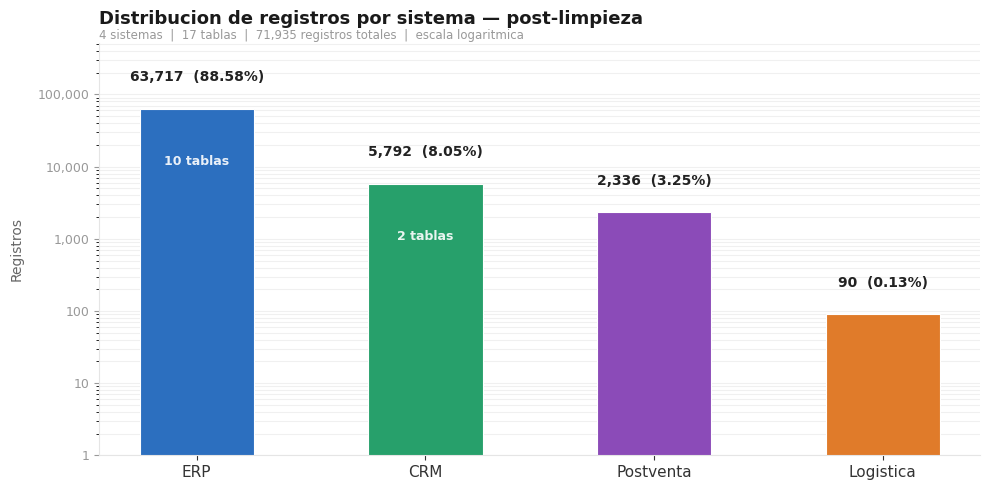

In [4]:
# ── Grafico: estado final por sistema ─────────────────────────────────────────
resumen = df_estado.groupby('sistema')['registros'].sum().sort_values(ascending=False)
colors  = [PALETA[s] for s in resumen.index]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

bars = ax.bar(resumen.index, resumen.values, color=colors,
              edgecolor='white', linewidth=0.8, width=0.5)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(1, resumen.max() * 8)

for bar, sistema, val in zip(bars, resumen.index, resumen.values):
    n_tab = len(SISTEMAS[sistema])
    pct   = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, val * 2.2,
            f'{val:,.0f}  ({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#222222')
    if val > total * 0.05:
        ax.text(bar.get_x() + bar.get_width() / 2, val * 0.15,
                f'{n_tab} tabla{"s" if n_tab > 1 else ""}',
                ha='center', va='bottom', fontsize=9,
                color='white', fontweight='bold', alpha=0.9)

ax.set_title('Distribucion de registros por sistema — post-limpieza', fontsize=13,
             fontweight='bold', color='#1A1A1A', pad=14, loc='left')
ax.text(0, 1.01,
        f'4 sistemas  |  17 tablas  |  {total:,.0f} registros totales  |  escala logaritmica',
        transform=ax.transAxes, fontsize=8.5, color='#999999')
ax.set_ylabel('Registros', fontsize=10, color='#666666', labelpad=10)
ax.tick_params(axis='x', labelsize=11, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#999999')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#E5E5E5')
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#F0F0F0', linewidth=0.8, which='both')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_estado_final_sistemas.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

---
## 7.3 — Decisiones técnicas clave

In [5]:
# ── Decisiones técnicas documentadas ─────────────────────────────────────────
DECISIONES = [
    {
        'id'          : 'D01',
        'ambito'      : 'Arquitectura',
        'decision'    : 'Una sola BD (saleshealth) con schemas stg, dwh y marts',
        'alternativa' : 'Dos BDs separadas (origen + DWH)',
        'razon'       : 'Simplifica la gestión de conexiones, los JOINs entre capas son directos y el despliegue es más sencillo. El aislamiento entre capas se mantiene igual mediante schemas.'
    },
    {
        'id'          : 'D02',
        'ambito'      : 'Calidad de datos',
        'decision'    : 'Nunca eliminar clientes, aunque tengan datos incorrectos',
        'alternativa' : 'Eliminar registros con datos inválidos',
        'razon'       : 'Regla de negocio establecida por la profesora. Los clientes con datos incorrectos se conservan con el error documentado.'
    },
    {
        'id'          : 'D03',
        'ambito'      : 'Corrección de datos',
        'decision'    : 'Precio producto 29 corregido a 99.90 EUR usando margen fijo del 40%',
        'alternativa' : 'Imputar por mediana de categoría o conservar precio incorrecto',
        'razon'       : 'Todos los productos de la categoría 1 tienen exactamente un 40% de margen. La lógica de negocio es clara y determinista: price = unit_cost / 0.60 = 59.94 / 0.60 = 99.90.'
    },
    {
        'id'          : 'D04',
        'ambito'      : 'Corrección de datos',
        'decision'    : 'subtotal y total son campos derivados — items son fuente de verdad',
        'alternativa' : 'Conservar los valores originales aunque sean incorrectos',
        'razon'       : 'Los campos derivados deben ser consistentes con sus componentes. Se recalculan P07 (subtotales) antes que P08 (totales) para garantizar el orden correcto.'
    },
    {
        'id'          : 'D05',
        'ambito'      : 'Schema real vs asumido',
        'decision'    : 'Exploración directa de la BD para descubrir el schema real',
        'alternativa' : 'Asumir nombres de columnas estándar sin verificar',
        'razon'       : 'El schema real difiere significativamente de las asunciones iniciales: name en lugar de product_name, unit_cost en lugar de cost, FKs en central_product en lugar de product, etc. La exploración directa es imprescindible.'
    },
    {
        'id'          : 'D06',
        'ambito'      : 'Métricas adicionales',
        'decision'    : 'AOV (Average Order Value) y Return Rate como métricas adicionales al CLTV',
        'alternativa' : 'Churn scoring, RFM u otras métricas',
        'razon'       : 'AOV y Return Rate tienen relación directa con los datos disponibles y son accionables para el negocio. El AOV diferencia tipos de comprador y el Return Rate afecta directamente al margen real del CLTV.'
    },
]

print('=' * 72)
print('  DECISIONES TÉCNICAS CLAVE — FASE 1')
print('=' * 72)
for d in DECISIONES:
    print(f"\n  [{d['id']}] {d['ambito'].upper()}")
    print(f"  Decisión     : {d['decision']}")
    print(f"  Alternativa  : {d['alternativa']}")
    print(f"  Razon        : {d['razon']}")
print(f"\n{'='*72}")

  DECISIONES TÉCNICAS CLAVE — FASE 1

  [D01] ARQUITECTURA
  Decisión     : Una sola BD (saleshealth) con schemas stg, dwh y marts
  Alternativa  : Dos BDs separadas (origen + DWH)
  Razon        : Simplifica la gestión de conexiones, los JOINs entre capas son directos y el despliegue es más sencillo. El aislamiento entre capas se mantiene igual mediante schemas.

  [D02] CALIDAD DE DATOS
  Decisión     : Nunca eliminar clientes, aunque tengan datos incorrectos
  Alternativa  : Eliminar registros con datos inválidos
  Razon        : Regla de negocio establecida por la profesora. Los clientes con datos incorrectos se conservan con el error documentado.

  [D03] CORRECCIÓN DE DATOS
  Decisión     : Precio producto 29 corregido a 99.90 EUR usando margen fijo del 40%
  Alternativa  : Imputar por mediana de categoría o conservar precio incorrecto
  Razon        : Todos los productos de la categoría 1 tienen exactamente un 40% de margen. La lógica de negocio es clara y determinista: price = 

---
## 7.4 — Datos listos para el DWH

In [6]:
# ── Checks finales de certificación ──────────────────────────────────────────
checks = []

# 1. Integridad referencial
FKS = [
    ('sale', 'customer_id', 'customer', 'customer_id'),
    ('sale', 'store_id', 'store', 'store_id'),
    ('sale_item', 'sale_id', 'sale', 'sale_id'),
    ('sale_item', 'product_id', 'product', 'product_id'),
    ('return_item', 'sale_item_id', 'sale_item', 'sale_item_id'),
    ('return_item', 'reason_id', 'return_reason', 'reason_id'),
    ('inventory', 'store_id', 'store', 'store_id'),
    ('inventory', 'product_id', 'product', 'product_id'),
    ('central_product', 'category_id', 'category', 'category_id'),
    ('central_product', 'brand_id', 'brand', 'brand_id'),
]
fk_errors = 0
for th, cfk, tp, cpk in FKS:
    n = int(query(f"SELECT COUNT(*) AS n FROM {th} h LEFT JOIN {tp} p ON h.{cfk}=p.{cpk} WHERE h.{cfk} IS NOT NULL AND p.{cpk} IS NULL")['n'].iloc[0])
    if n > 0: fk_errors += 1
checks.append(('Integridad referencial (10 FKs)', fk_errors == 0, f'{10-fk_errors}/10 OK'))

# 2. Margenes negativos
n_neg = int(query("SELECT COUNT(*) AS n FROM product p JOIN central_product cp ON p.product_id=cp.product_id WHERE p.price < cp.unit_cost")['n'].iloc[0])
checks.append(('Productos con precio < coste', n_neg == 0, f'{n_neg} casos'))

# 3. Subtotales inconsistentes
n_sub = int(query("SELECT COUNT(*) AS n FROM sale_item WHERE ABS(subtotal - ROUND(quantity * unit_price, 2)) > 0.01")['n'].iloc[0])
checks.append(('Subtotales inconsistentes', n_sub == 0, f'{n_sub} casos'))

# 4. Totales de venta inconsistentes
n_tot = len(query("""
    SELECT s.sale_id FROM sale s JOIN sale_item si ON s.sale_id=si.sale_id
    GROUP BY s.sale_id, s.total HAVING ABS(s.total - SUM(si.subtotal)) > 0.01
"""))
checks.append(('Totales de venta inconsistentes', n_tot == 0, f'{n_tot} casos'))

# 5. Clientes sin ventas
n_sin_venta = int(query("""
    SELECT COUNT(*) AS n FROM customer c
    LEFT JOIN sale s ON c.customer_id = s.customer_id
    WHERE s.sale_id IS NULL
""")['n'].iloc[0])
checks.append(('Clientes sin ninguna venta', n_sin_venta == 0, f'{n_sin_venta} clientes'))

# 6. Productos sin coste
n_sin_coste = int(query("""
    SELECT COUNT(*) AS n FROM product p
    LEFT JOIN central_product cp ON p.product_id = cp.product_id
    WHERE cp.unit_cost IS NULL OR cp.unit_cost = 0
""")['n'].iloc[0])
checks.append(('Productos sin coste registrado', n_sin_coste == 0, f'{n_sin_coste} productos'))

# 7. Devoluciones sin venta asociada
n_dev = int(query("""
    SELECT COUNT(*) AS n FROM return_item ri
    LEFT JOIN sale_item si ON ri.sale_item_id = si.sale_item_id
    WHERE si.sale_item_id IS NULL
""")['n'].iloc[0])
checks.append(('Devoluciones sin venta asociada', n_dev == 0, f'{n_dev} casos'))

# ── Print de certificación ────────────────────────────────────────────────────
print('=' * 68)
print('  CERTIFICACIÓN FINAL — Base de datos lista para el DWH')
print(f'  Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 68)
print(f'  {"CHECK":<40} {"RESULTADO":<12}  ESTADO')
print('-' * 68)
todos_ok = True
for label, ok, detalle in checks:
    estado = '✅ OK' if ok else '⚠  REVISAR'
    if not ok: todos_ok = False
    print(f'  {label:<40} {detalle:<12}  {estado}')
print('=' * 68)
print()
if todos_ok:
    print('  ✅ CERTIFICACIÓN APROBADA')
    print('  La base de datos saleshealth está en estado correcto.')
    print('  Puede procederse con la construcción del Data Warehouse.')
else:
    print('  ⚠  Hay checks que no pasan. Revisar antes de continuar.')
print('=' * 68)

  CERTIFICACIÓN FINAL — Base de datos lista para el DWH
  Fecha: 2026-05-02 15:35:45
  CHECK                                    RESULTADO     ESTADO
--------------------------------------------------------------------
  Integridad referencial (10 FKs)          10/10 OK      ✅ OK
  Productos con precio < coste             0 casos       ✅ OK
  Subtotales inconsistentes                0 casos       ✅ OK
  Totales de venta inconsistentes          0 casos       ✅ OK
  Clientes sin ninguna venta               0 clientes    ✅ OK
  Productos sin coste registrado           0 productos   ✅ OK
  Devoluciones sin venta asociada          0 casos       ✅ OK

  ✅ CERTIFICACIÓN APROBADA
  La base de datos saleshealth está en estado correcto.
  Puede procederse con la construcción del Data Warehouse.


---
## 7.5 — Próximos pasos

Con la Fase 1 completada y certificada, el proyecto continúa con la construcción
del entorno analítico:

In [7]:
# ── Hoja de ruta completa del proyecto ────────────────────────────────────────
HOJA_RUTA = [
    ('FASE 1', 'Exploración y Limpieza',      '7 notebooks',  '✅ COMPLETADA'),
    ('FASE 2', 'Modelo Entidad-Relación',      'Diagrama ER',  '⬜ SIGUIENTE'),
    ('FASE 3', 'Modelo Dimensional',           'DDL + diagrama estrella', '⬜'),
    ('FASE 4', 'ETL automatizado',             'Pipeline Python completo', '⬜'),
    ('FASE 5', 'CLTV + AOV + Return Rate',     'Métricas de cliente', '⬜'),
    ('FASE 6', 'PCA + Clustering',             'Segmentación K-Means', '⬜'),
    ('FASE 7', 'Dashboard Streamlit',          '5 páginas interactivas', '⬜'),
    ('FASE 8', 'Documento técnico',            'Máx 5 hojas / 10 caras', '⬜'),
]

print('=' * 72)
print('  HOJA DE RUTA — Proyecto Final Gestión de Datos (UAX 2025/2026)')
print('=' * 72)
print(f'  {"FASE":<8} {"DESCRIPCION":<30} {"ENTREGABLE":<28} ESTADO')
print('-' * 72)
for fase, desc, entregable, estado in HOJA_RUTA:
    print(f'  {fase:<8} {desc:<30} {entregable:<28} {estado}')
print('=' * 72)
print('\nFase 1 completada. Siguiente paso: Modelo ER.')
print('\nFase 1 — Exploración y Limpieza completada y certificada.')

  HOJA DE RUTA — Proyecto Final Gestión de Datos (UAX 2025/2026)
  FASE     DESCRIPCION                    ENTREGABLE                   ESTADO
------------------------------------------------------------------------
  FASE 1   Exploración y Limpieza         7 notebooks                  ✅ COMPLETADA
  FASE 2   Modelo Entidad-Relación        Diagrama ER                  ⬜ SIGUIENTE
  FASE 3   Modelo Dimensional             DDL + diagrama estrella      ⬜
  FASE 4   ETL automatizado               Pipeline Python completo     ⬜
  FASE 5   CLTV + AOV + Return Rate       Métricas de cliente          ⬜
  FASE 6   PCA + Clustering               Segmentación K-Means         ⬜
  FASE 7   Dashboard Streamlit            5 páginas interactivas       ⬜
  FASE 8   Documento técnico              Máx 5 hojas / 10 caras       ⬜

Fase 1 completada. Siguiente paso: Modelo ER.

Fase 1 — Exploración y Limpieza completada y certificada.
